**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 17 -  📊 Introducción al análisis de inversiones con Python (II)**

## Complemento

Este notebook se complementa con la presentación: **Inversiones.pdf**

Te recomendamos leer el PDF para trabajar con este notebook y tener una mejor comprensión de los conceptos teóricos.

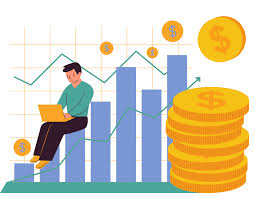

# 📐 Seguimos con las formulas:




6.   Tasa interna de retorno (TIR)
7.   Tasa interna de retorno modificada (TIRM)
8.   Indice de rentabilidad (IR)
9.   Periodo de recuperacion simple (PRS)
10.   Periodo de recuperacion descontado (PRD)

---











### ***6) Tasa Interna de Retorno (TIR)***

La Tasa Interna de Retorno (TIR) es la tasa de descuento que hace que el Valor Actual Neto (VAN) de todos los flujos de caja de un proyecto de inversión sea igual a cero. Representa la rentabilidad intrínseca del proyecto.

**La fórmula es implícita y generalmente requiere métodos iterativos para su cálculo:**

$$
\sum_{t=0}^{n} \frac{F_t}{(1+TIR)^t} = 0
$$

Donde:

-$ F_t $: Flujo de caja en el período \( t \)
- $ TIR $: Tasa Interna de Retorno
- $ t $: Período de tiempo
- $ n $: Número total de períodos

**Interpretación de la TIR:**

- Si **TIR > r** (Tasa de descuento o costo de capital): El proyecto es rentable y conviene aceptarlo.
- Si **TIR < r**: El proyecto no es rentable y no conviene aceptarlo.
- Si **TIR = r**: El proyecto es indiferente.

### 💡 La TIR en criollo

Ya vimos que el **VAN** depende de qué tasa de descuento elijas: con tasa baja da positivo, y a medida que subís la tasa el VAN baja… hasta que en algún punto se vuelve **cero** y después negativo.

👉 La **TIR es justamente esa tasa donde el VAN se hace cero.** Es el "punto de quiebre" del proyecto.

🎯 *Otra forma de verlo:* la TIR es **la rentabilidad propia del proyecto**, la tasa a la que el proyecto "empata" (ni gana ni pierde valor presente). Por eso la comparás contra tu costo de capital $r$:
- Si **TIR > r** → el proyecto rinde más de lo que te cuesta la plata → 👍 conviene.
- Si **TIR < r** → rinde menos de lo que te cuesta → 👎 no conviene.

🏔️ *Analogía:* pensá la tasa de descuento como **la altura del agua** y el VAN como **una isla**. Con poca agua (tasa baja) la isla asoma (VAN positivo). A medida que sube el agua, la isla se hunde. La **TIR es el nivel exacto de agua que deja la isla justo al ras** (VAN = 0). Si tu costo de capital es *menor* que ese nivel, todavía tenés tierra firme.

> ⚠️ **Ojo:** la TIR no tiene fórmula directa, se busca por iteración (por eso usamos `nf.irr`). Y tiene una trampa que vamos a ver con la TIRM 👇

## Caso NVDA 🤖

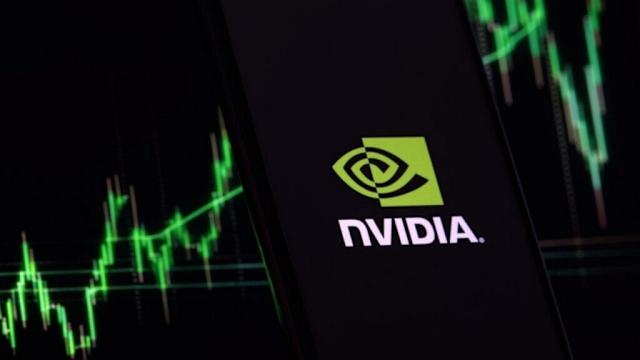

In [2]:
import yfinance as yf #traemos info del mercado 15´ retrasados
import pandas as pd

#ticker de la empresa a analizar
ticker_symbol = "NVDA" #Podemos analizar cualquier empresa que cotice en el mercado

# Descargar la info del mercado
ticker_data = yf.Ticker(ticker_symbol)
df = ticker_data.history(period="5y") # Se puede ajustar el periodo de analisis.
display(df.head())

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-05-26 00:00:00-04:00,15.694693,15.754043,15.547066,15.660529,370440000,0.0,0.0
2021-05-27 00:00:00-04:00,15.660277,15.710401,15.421130,15.449059,581476000,0.0,0.0
2021-05-28 00:00:00-04:00,15.462028,16.236575,15.462028,16.203657,644536000,0.0,0.0
2021-06-01 00:00:00-04:00,16.229093,16.347046,15.863264,16.223606,472804000,0.0,0.0
2021-06-02 00:00:00-04:00,16.211394,16.876218,16.194686,16.736071,594168000,0.0,0.0


In [3]:
#Nos quedamos con el cierre de la fecha
df_selected = df[['Close']]
display(df_selected.head())

,Close
Date,
2021-05-26 00:00:00-04:00,15.660529
2021-05-27 00:00:00-04:00,15.449059
2021-05-28 00:00:00-04:00,16.203657
2021-06-01 00:00:00-04:00,16.223606
2021-06-02 00:00:00-04:00,16.736071


In [4]:
df_selected

,Close
Date,
2021-05-26 00:00:00-04:00,15.660529
2021-05-27 00:00:00-04:00,15.449059
2021-05-28 00:00:00-04:00,16.203657
2021-06-01 00:00:00-04:00,16.223606
2021-06-02 00:00:00-04:00,16.736071
...,...
2026-05-19 00:00:00-04:00,220.610001
2026-05-20 00:00:00-04:00,223.470001
2026-05-21 00:00:00-04:00,219.509995


In [5]:
df_selected['Year'] = df_selected.index.year
df_PROMAÑO = df_selected.groupby('Year')['Close'].mean().reset_index()


df_PROMAÑO.columns = ['Año', 'Promedio de Cierre de Acción']
display(df_PROMAÑO)

C:\Users\C5099702\AppData\Local\Temp\ipykernel_7472\1904090759.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Year'] = df_selected.index.year


,Año,Promedio de Cierre de Acción
0,2021,23.074909
1,2022,18.538111
2,2023,36.540525
3,2024,107.774187
4,2025,153.874946
5,2026,191.515030


In [6]:
#  nueva columna 'cantidad de acciones compradas' todo valor 0
df_PROMAÑO['cantidad de acciones compradas'] = 0

# excepto el primer elemento
df_PROMAÑO.loc[0, 'cantidad de acciones compradas'] = 10
display(df_PROMAÑO)

,Año,Promedio de Cierre de Acción,cantidad de acciones compradas
0,2021,23.074909,10
1,2022,18.538111,0
2,2023,36.540525,0
3,2024,107.774187,0
4,2025,153.874946,0
5,2026,191.515030,0


> ⚠️ **Aclaración importante.** Una acción sin dividendos no paga un flujo cada año: la ganancia/pérdida es "en papel" (no realizada) hasta que vendés. Para poder ilustrar la TIR con varios períodos, modelamos la posición como un esquema **total-return / mark-to-market**: cada año "liquidamos" la variación de precio del año (como en una posición apalancada o un total-return swap) y, al cierre, **recuperamos el notional original** que pusimos al comprar.
>

In [7]:
# Compra inicial: compramos q acciones al precio promedio del Año 0
q  = df_PROMAÑO.loc[0, 'cantidad de acciones compradas']
P0 = df_PROMAÑO.loc[0, 'Promedio de Cierre de Acción']
inversion_inicial = -P0 * q

# iNGRESOS:
#  - Año 0: desembolsamos el notional (compra)            -> -P0*q
#  - Años intermedios: liquidamos la VARIACIÓN de precio  -> diff * q
#  - Año final: liquidamos la última variación Y recuperamos
#               el NOTIONAL ORIGINAL (P0*q).

df_PROMAÑO['Flujo'] = df_PROMAÑO['Promedio de Cierre de Acción'].diff() * q
df_PROMAÑO.loc[0, 'Flujo'] = inversion_inicial

ultimo = df_PROMAÑO.index[-1]
df_PROMAÑO.loc[ultimo, 'Flujo'] = df_PROMAÑO.loc[ultimo, 'Flujo'] + P0 * q

# Chequeo de consistencia: la suma de flujos debe ser la ganancia total = (P_final - P0)*q
ganancia_esperada = (df_PROMAÑO.loc[ultimo, 'Promedio de Cierre de Acción'] - P0) * q
assert abs(df_PROMAÑO['Flujo'].sum() - ganancia_esperada) < 1e-6, "Doble conteo en los flujos"

display(df_PROMAÑO)

,Año,Promedio de Cierre de Acción,cantidad de acciones compradas,Flujo
0,2021,23.074909,10,-230.749093
1,2022,18.538111,0,-45.367982
2,2023,36.540525,0,180.024140
3,2024,107.774187,0,712.336615
4,2025,153.874946,0,461.007592
5,2026,191.515030,0,607.149934


In [8]:
# !pip install numpy_financial

###  ¿Qué es `numpy-financial`?

`numpy-financial` es una librería de Python que reúne funciones financieras comunes, separada de NumPy para mantenerla enfocada en cálculos numéricos generales. Permite realizar:

*   **Cálculos de valor presente y futuro** (por ejemplo, `npf.pv()`, `npf.fv()`), útiles para valorar inversiones.
*   **Análisis de flujos de caja** (por ejemplo, `npf.irr()`, `npf.npv()`), esenciales para evaluar la rentabilidad de proyectos.
*   **Cálculos de anualidades**, aplicables a préstamos, hipotecas o planes de ahorro.
*   **Operaciones básicas con bonos y valores**.

En síntesis, es una herramienta práctica para realizar cálculos financieros de forma eficiente, especialmente al trabajar con grandes conjuntos de datos numéricos. 📊

In [9]:
#Dataframe ready para utilizar con nuestras herramientas ;)
display(df_PROMAÑO)

,Año,Promedio de Cierre de Acción,cantidad de acciones compradas,Flujo
0,2021,23.074909,10,-230.749093
1,2022,18.538111,0,-45.367982
2,2023,36.540525,0,180.024140
3,2024,107.774187,0,712.336615
4,2025,153.874946,0,461.007592
5,2026,191.515030,0,607.149934


In [10]:
import numpy_financial as nf

# Calculamos tir
tir = nf.irr(df_PROMAÑO['Flujo'])
print(f"La Tasa Interna de Retorno (TIR) es: {tir:.2%}")

La Tasa Interna de Retorno (TIR) es: 79.50%


---
### 🧱 Primero lo primero: ¿qué es el "costo de capital" (la r)?

Antes de comparar nada, frenemos en la `r`, porque es el concepto que hace funcionar **todo** el análisis de inversiones.

El **costo de capital** es **lo que te cuesta usar la plata** en un proyecto. Y "cuesta" aunque la plata sea tuya, porque siempre hay un **costo de oportunidad**: si la metés acá, la dejás de meter en otro lado.

💡 La plata nunca está "gratis ni quieta". Si no invertís en este proyecto, igual podrías:
- dejarla en un plazo fijo ganando intereses,
- comprar un bono,
- o comprar el mercado (un índice como el S&P 500).

Ese **"lo que ganaría en mi mejor alternativa"** es tu costo de capital. Es el **mínimo que le exigís** a cualquier inversión para que valga la pena: si un proyecto no te da *al menos* eso, te conviene la alternativa.

> 🧭 **Por eso la `r` aparece en todas las fórmulas** (VAN, VP, IR, PRD): es la tasa a la que descontás. Le estás preguntando a cada peso futuro: *"¿valés más que lo que yo podría ganar en mi mejor alternativa?"*. Si la respuesta es sí para el conjunto del proyecto (VAN > 0, o TIR > r), conviene.

Ahora la pregunta práctica: **¿qué número uso como `r`?** Necesito una alternativa concreta y medible… y ahí entra el mercado. 👇

### 🎯 ¿Qué tasa de descuento (r) usamos? El rendimiento del mercado

Para decidir si NVDA fue una buena inversión, necesitamos una **vara de comparación**: ¿comparado con qué? La respuesta correcta es el **costo de oportunidad** → lo que habríamos ganado poniendo esa misma plata en la **alternativa más obvia: el mercado entero**.

Esa alternativa es el **S&P 500**, el índice de las 500 empresas más grandes de EE.UU., que se puede comprar con un solo ticker: **SPY**. Es el "rendimiento por defecto" de cualquier inversor: si no elegís ninguna acción en particular, comprás el mercado y listo.

👉 Entonces nuestra pregunta pasa a ser la que se hace **todo inversor profesional**:

> *¿Invertir en NVDA rindió **más que simplemente haber comprado el mercado**?*

- Si **TIR de NVDA > rendimiento del SPY** → NVDA **le ganó al mercado** → valió la pena el riesgo. 👍
- Si **TIR < rendimiento del SPY** → habría convenido comprar el índice y ahorrarse el riesgo. 👎

> 🧮 **¿Cómo medimos el rendimiento del SPY?** Usamos el **CAGR** (tasa de crecimiento anual compuesta): la tasa anual *efectiva* que, capitalizada, lleva del precio inicial al final. La usamos —y no el simple promedio de las variaciones anuales— porque **es una tasa efectiva, directamente comparable con la TIR** (que también es una tasa efectiva). El promedio de variaciones sobreestima, porque ignora la capitalización y la volatilidad.

In [11]:
import yfinance as yf

# Traemos SPY con la MISMA herramienta y período que NVDA
spy_data = yf.Ticker("SPY")
df_spy = spy_data.history(period="5y").copy()   # .copy() evita SettingWithCopyWarning

# MISMA convención que NVDA: promedio de cierre por año calendario
df_spy['Year'] = df_spy.index.year
spy_anual = df_spy.groupby('Year')['Close'].mean()

# Nº de períodos anuales: tiene que coincidir con el de NVDA para que TIR y r sean comparables
n_periodos = len(spy_anual) - 1
assert n_periodos == len(df_PROMAÑO) - 1, \
    "NVDA y SPY no cubren el mismo nº de períodos anuales; alineá los años antes de comparar"

# CAGR de la serie de promedios anuales: (P_k / P_0)^(1/k) - 1

precio_inicial = spy_anual.iloc[0]
precio_final   = spy_anual.iloc[-1]
r_mercado = (precio_final / precio_inicial) ** (1 / n_periodos) - 1

print(f"Períodos anuales: {n_periodos}")
print(f"Rendimiento anualizado del S&P 500 (CAGR sobre promedios anuales): {r_mercado:.2%}")
print(f"-> Tasa de descuento r: costo de oportunidad de NO comprar el mercado.")

Períodos anuales: 5
Rendimiento anualizado del S&P 500 (CAGR sobre promedios anuales): 10.58%
-> Tasa de descuento r: costo de oportunidad de NO comprar el mercado.


**¿NVDA le ganó al mercado?** 🥊

Si la **TIR de NVDA supera el rendimiento del S&P 500 (`r_mercado`)**, entonces invertir en NVDA rindió **más que comprar el mercado entero** → fue una decisión acertada que justificó asumir el riesgo de apostar a una sola empresa.

Si en cambio la TIR hubiera quedado **por debajo**, la conclusión sería la contraria: convenía comprar el índice (SPY), obtener el rendimiento del mercado y evitar el riesgo de concentrarse en una acción.

> 🎯 Esta es exactamente la lógica que usan los fondos de inversión: comparar todo contra el "benchmark" del mercado. Superar al S&P 500 de forma consistente es, de hecho, muy muy muy difícil; por eso cuando una inversión lo logra, es noticia.

---

## ***7) Tasa Interna de Retorno Modificada (TIRM)***

La Tasa Interna de Retorno Modificada (TIRM) aborda una de las críticas de la TIR tradicional: la suposición de que los flujos de caja intermedios se reinvierten a la propia TIR. La TIRM asume que los flujos de caja positivos se reinvierten a una tasa de reinversión específica (generalmente el costo de capital), y los flujos de caja negativos se descuentan al costo de financiamiento.

**Fórmula de la TIRM:**

$$
TIRM = \left( \frac{VF_{positivos}}{VP_{negativos}} \right)^{\frac{1}{n}} - 1
$$

Donde:

- $ VF_{positivos} $: Valor futuro de los flujos de caja positivos (reinvertidos a la tasa de reinversión).
- $ VP_{negativos} $: Valor presente de los flujos de caja negativos (descontados al costo de financiamiento, en caso de que te financies con un préstamo).
- $ n $: Número total de períodos.

**Interpretación de la TIRM:**

- Si **TIRM > r** (Tasa de reinversión/costo de capital): El proyecto es rentable y conviene aceptarlo.
- Si **TIRM < r**: El proyecto no es rentable y no conviene aceptarlo.
- Si **TIRM = r**: El proyecto es indiferente.

### 💡 ¿Por qué necesitamos la TIRM? Porque hay un supuesto oculto en la TIR

La TIR asume que **cada peso que el proyecto te devuelve, lo reinvertís a la misma TIR**.

🤔 ¿Por qué es un problema? Si tu proyecto tiene una TIR del 95%, la TIR está suponiendo que los flujos que cobrás los volvés a colocar **¡también al 95%!** — algo casi imposible en la vida real. Eso **infla** artificialmente la rentabilidad.

La **TIRM** corrige esto separando dos tasas realistas:
- 💰 Los flujos **positivos** que cobrás los reinvertís a una tasa **alcanzable** (tu costo de capital, no la TIR fantástica).
- 🏦 Los flujos **negativos** los descontás a tu tasa de financiamiento.


> Si  TIR y TIRM están cerca, el proyecto no depende mucho del supuesto de reinversión. Si están muy separadas (como en el caso NVDA), cuidado: buena parte del atractivo de la TIR venía de ese supuesto optimista.

In [12]:
import numpy_financial as npf

# La TIRM usa una tasa de financiamiento (costo de la deuda) y una de reinversión.
# Usamos el rendimiento del mercado (SPY) como referencia realista para ambas:
# es lo que rendirían los flujos si los reinvirtiéramos en el índice.
tasa_financiamiento = r_mercado
tasa_reinversion    = r_mercado

tirm_result = npf.mirr(df_PROMAÑO['Flujo'].tolist(), tasa_financiamiento, tasa_reinversion)
print(f"Tasa de mercado usada (financiamiento y reinversión): {r_mercado:.2%}")
print(f"La Tasa Interna de Retorno Modificada (TIRM) es: {tirm_result:.2%}")

Tasa de mercado usada (financiamiento y reinversión): 10.58%
La Tasa Interna de Retorno Modificada (TIRM) es: 52.36%


TIRM > r. Es rentable

---

## ***8) Índice de Rentabilidad (IR)***

El Índice de Rentabilidad (IR), también conocido como relación beneficio/costo, mide **cuánto valor presente generan los flujos futuros por cada peso invertido**. Se calcula dividiendo el valor presente de los flujos de caja **futuros** (excluyendo la inversión inicial) entre la inversión inicial.

**Fórmula del IR:**

$$
IR = \frac{\sum_{t=1}^{n} \dfrac{F_t}{(1+r)^t}}{I_0}
$$

Donde:

- $ F_t $: flujo de caja del período $t$ (con $t \geq 1$, es decir **sin** contar la inversión inicial)
- $ I_0 $: inversión inicial (en valor absoluto)
- $ r $: tasa de descuento

> 🔗 **Relación útil con el VAN:** como $VAN = -I_0 + \sum_{t=1}^{n}\frac{F_t}{(1+r)^t}$, se cumple que
> $$IR = 1 + \frac{VAN}{I_0}$$
> Por eso el umbral del IR es **1** (no 0): cuando $VAN = 0$, el $IR = 1$. Ojo: $IR \neq VAN/I_0$.

**Interpretación del IR:**

- Si **IR > 1**: el valor presente de los beneficios supera la inversión → proyecto rentable. Conviene aceptarlo.
- Si **IR < 1**: el valor presente de los beneficios es menor que la inversión → no conviene.
- Si **IR = 1**: el proyecto es indiferente (equivale a $VAN = 0$).

In [13]:
import numpy_financial as nf

# Tasa de descuento = rendimiento del mercado (SPY). Es el costo de oportunidad:
# lo que habríamos ganado invirtiendo en el índice en vez de en NVDA.
r_desc_ir = r_mercado

# Flujos del proyecto NVDA
flujos_ir = df_PROMAÑO['Flujo'].tolist()
I_inicial = abs(flujos_ir[0])

# VP de los flujos FUTUROS (t = 1..n), descontando cada uno en su período real.
vp_flujos_futuros = sum(f / (1 + r_desc_ir)**t for t, f in enumerate(flujos_ir[1:], start=1))

ir = vp_flujos_futuros / I_inicial
print(f"Tasa de descuento usada (rendimiento del mercado): {r_desc_ir:.2%}")
print(f"El Índice de Rentabilidad (IR) es: {ir:.2f}")

Tasa de descuento usada (rendimiento del mercado): 10.58%
El Índice de Rentabilidad (IR) es: 5.67


IR > 1: rentable

---

## ***9) Periodo de Recuperación Simple (PRS)***

El Periodo de Recuperación Simple (PRS) es el tiempo que tarda un proyecto de inversión en recuperar la inversión inicial con los flujos de caja brutos (sin descontar). Es una medida de liquidez, no de rentabilidad.

**Cálculo del PRS:**

Se calcula sumando los flujos de caja anuales hasta que la suma sea igual o mayor que la inversión inicial. Si la recuperación ocurre dentro de un año, se puede interpolar linealmente.

**Interpretación del PRS:**

Generalmente, se compara con un período de recuperación máximo aceptable definido por la empresa. Proyectos con PRS más cortos suelen ser preferibles, ya que recuperan la inversión más rápido, aunque no considera la rentabilidad después del período de recuperación ni el valor del dinero en el tiempo.

In [ ]:
#flujos como una lista
flujos_prs = df_PROMAÑO['Flujo'].tolist()

#inversión inicial
I_inicial = abs(flujos_prs[0])

# Inicializar variables para el flujo de caja acumulado y el período de recuperación
cash_flow_acumulado = 0 #el flujo de caja acumulativo comienza en 0
prs = None

# luego , Iterar a través de los flujos de caja comenzando desde el primer período (después de la inversión inicial)
for t in range(1, len(flujos_prs)):
    cash_flow_acumulado += flujos_prs[t]

    # Verificar si el flujo de caja acumulado es mayor o igual a la inversión inicial
    if cash_flow_acumulado >= I_inicial:
        # Si es así, calcular el período de recuperación
        # El período de recuperación es el período actual 't' más la fracción del flujo del último período necesaria para cubrir la inversión restante
        inversion_restante = I_inicial - (cash_flow_acumulado - flujos_prs[t])
        prs = t - 1 + (inversion_restante / flujos_prs[t])
        break

# Mostrar el Periodo de Recuperación Simple (PRS) calculado
if prs is not None:
    print(f"El Periodo de Recuperación Simple (PRS) es: {prs:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis.")

El Periodo de Recuperación Simple (PRS) es: 2.13 años


Si yo hubiese comprado las acciones, luego de 2 años y un poquito  habría estado recuperado mi inversion Inicial.

---

## ***10) Periodo de Recuperación Descontado (PRD)***

El Periodo de Recuperación Descontado (PRD) es similar al PRS, pero utiliza los flujos de caja descontados para calcular el tiempo que tarda en recuperarse la inversión inicial. Esta métrica sí considera el valor del dinero en el tiempo.

**Cálculo del PRD:**

Se calcula sumando los flujos de caja descontados anualmente hasta que la suma sea igual o mayor que la inversión inicial.

**Interpretación del PRD:**

Al igual que el PRS, se compara con un período de recuperación máximo aceptable. El PRD siempre será mayor que el PRS (o igual si la tasa de descuento es cero). Proyectos con PRD más cortos son generalmente preferibles, pero sigue sin considerar la rentabilidad después del período de recuperación.

In [ ]:
# Definir la tasa de descuento (usando la misma tasa que para VAN/IR)
r_desc_prd = r_desc_ir

# Obtener los flujos de caja como una lista
flujos_prd = df_PROMAÑO['Flujo'].tolist()

# Obtener la inversión inicial (valor absoluto del primer flujo de caja)
I_inicial = abs(flujos_prd[0])

# Misma historia
cash_flow_acumulado_descontado = 0
prd = None

# Misma historia
for t in range(1, len(flujos_prd)):
    # Descontar el flujo de caja actual
    discounted_flow = flujos_prd[t] / (1 + r_desc_prd)**t # aaaaa pero aca cambia se descuentan los flujos periodo periodo por la tasa de costo de capital.
    cash_flow_acumulado_descontado += discounted_flow

    # Verificar si el flujo de caja descontado acumulado es mayor o igual a la inversión inicial
    if cash_flow_acumulado_descontado >= I_inicial:
        # Si es así, calcular el período de recuperación descontado
        # El período de recuperación descontado es el período actual 't' más la fracción del flujo descontado del último período necesaria para cubrir la inversión restante
        inversion_restante = I_inicial - (cash_flow_acumulado_descontado - discounted_flow)
        prd = t - 1 + (inversion_restante / discounted_flow)
        break

if prd is not None:
    print(f"El Periodo de Recuperación Descontado (PRD) es: {prd:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis descontado.")

El Periodo de Recuperación Descontado (PRD) es: 2.24 años


---

In [16]:
# !pip install numpy_financial

numpy financial es un atajo por que no lo usamos??

| Tipo de cálculo               | ¿Disponible en `numpy-financial`? |
| ----------------------------- | :-------------------------------: |
| Equivalencia                  |                 ❌                 |
| Proporción                    |                 ❌                 |
| Valor Presente (PV)           |                 ✅                 |
| Valor Futuro (FV)             |                 ✅                 |
| Valor Actual Neto (VAN / NPV) |                 ✅                 |
| TIR                           |                 ✅                 |
| TIRM                          |                 ✅                 |
| Índice de Rentabilidad (IR)   |        ❌        |
| PRS                           |             ❌            |
| PRD                           |     ❌      |


Pueden utilizar atajos en vez de hacer toooda las ecuaciones, los ejemplos son de la clase de hoy. pero la clase pasada hay muchas de las ecuaciones que son sencillas de hacer en con numpy financial y nos ahorran tiempo.

* VAN

In [17]:
import numpy_financial as nf

# Definir la tasa de descuento (usando la misma tasa que para el PRD)
tasa_descuento_van = r_desc_prd

# Obtener los flujos de caja como una lista
flujos_van = df_PROMAÑO['Flujo'].tolist()

# npf.npv(tasa, valores) calcula el valor presente neto de una serie de flujos de caja periódicos.
# El primer valor en la lista 'valores' es el flujo de caja en el momento 0.
resultado_van = nf.npv(tasa_descuento_van, flujos_van)
print(f"El Valor Presente Neto (VAN/NPV) de los flujos de NVDA es: {resultado_van:.2f}")

El Valor Presente Neto (VAN/NPV) de los flujos de NVDA es: 1077.65


* Valor presente

In [18]:
flujo = 1000
periodos = 5
tasa = 0.1

vp = nf.pv(rate=tasa, nper=periodos, pmt=flujo, fv=0, when='end') #fv=0 porque no hay valor futuro establecido , los pagos se reciben al final dado que son acciones, end.
print(f"Valor Presente (VP) de la anualidad: {abs(vp):.2f}")

Valor Presente (VP) de la anualidad: 3790.79


* Valor futuro

In [19]:
flujo = 1000
periodos = 5
tasa = 0.1

vf = nf.fv(rate=tasa, nper=periodos, pmt=flujo, pv=0, when='end') #pv=0 porque no hay valor presente establecido , los pagos se reciben al final dado que son acciones, end.
print(f"Valor Futuro (VF) de la anualidad: {abs(vf):.2f}")

Valor Futuro (VF) de la anualidad: 6105.10


## Resumen breve de Valor Presente (VP) y Valor Futuro (VF)

Estas son operaciones de equivalencia temporal aplicadas a flujos de dinero concretos, no a tasas. Sirven para llevar flujos de efectivo en el tiempo a un punto común (presente o futuro).

**Ejemplo:**

💡 Querés saber cuánto valen hoy (VP) o cuánto valdrán en 5 años (VF) pagos de 1000 $ anuales al 10%.

### Cálculo del Valor Presente (VP):

La fórmula general para el Valor Presente de una serie de flujos desiguales es:

$$
VP = \sum_{t=1}^{n} \frac{F_t}{(1+r)^t}
$$

Para una anualidad (pagos iguales), se puede usar la fórmula simplificada o `numpy_financial.pv()`:

$$
VP_{anualidad} = PMT \times \frac{1 - (1+r)^{-n}}{r}
$$

### Cálculo del Valor Futuro (VF):

La fórmula general para el Valor Futuro de una serie de flujos desiguales es más compleja y depende del momento en que ocurren los flujos. Para una anualidad (pagos iguales), se puede usar la fórmula simplificada o `numpy_financial.fv()`:

$$
VF_{anualidad} = PMT \times \frac{(1+r)^n - 1}{r}
$$

* Estas fórmulas te “trasladan dinero en el tiempo”. No cambian la tasa, sino que usan la tasa dada para traer o llevar montos.

## Resumen Breve de Equivalencia y Proporción de Tasas

Estas son operaciones entre tasas de interés, no entre flujos. Sirven para convertir tasas que están expresadas en distintos períodos o bases (por ejemplo, de mensual a anual, o de nominal a efectiva).

** Ejemplo:**

💡Si tenés una tasa mensual del 2 %, su equivalente anual efectiva es:

$$
Tasa Anual Efectiva = (1 + Tasa\ Mensual)^{12} - 1 = (1+0.02)^{12} - 1 \approx 0.2682 = 26.82\%
$$

O, al revés, si tenés una tasa efectiva anual del 26.82 %, la mensual equivalente es:

$$
Tasa Mensual Equivalente = (1 + Tasa\ Anual\ Efectiva)^{1/12} - 1 = (1+0.2682)^{1/12} - 1 \approx 0.02 = 2\%
$$

* Es decir, la equivalencia de tasas transforma una tasa en otra que produce el mismo efecto financiero, pero en distinto período. La proporción de tasas (que no se mostró en el ejemplo pero es relevante) simplemente escala una tasa nominal a diferentes períodos sin considerar la capitalización (por ejemplo, una tasa nominal anual del 12% pagadera mensualmente sería 1% mensual simple, 12%/12).

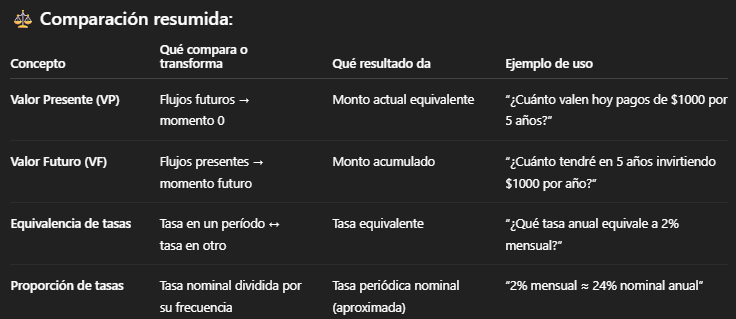

---

## 🧭 Repaso: ¿qué pregunta responde cada métrica?

Todas miran el mismo proyecto, pero contestan preguntas distintas.

| Métrica | La pregunta que responde | Unidad | Umbral | Mira el valor del dinero en el tiempo |
|---|---|---|---|---|
| **VAN** | ¿Cuánta plata *en valor de hoy* me deja el proyecto, neto de lo invertido? | $ | > 0 | ✅ |
| **TIR** | ¿A qué tasa "empata" el proyecto (VAN = 0)? ¿Cuánto rinde por sí mismo? | % anual | > r | ✅ |
| **TIRM** | Lo mismo que la TIR, pero **sin** el supuesto irreal de reinvertir a la propia TIR | % anual | > r | ✅ |
| **IR** | ¿Cuánto valor presente genero por **cada peso** invertido? | veces | > 1 | ✅ |
| **PRS** | ¿En cuánto tiempo recupero lo invertido (con plata sin descontar)? | años | < máximo aceptable | ❌ |
| **PRD** | ¿En cuánto tiempo lo recupero **descontando** los flujos? | años | < máximo aceptable | ✅ |

### Cómo se complementan

- **VAN vs TIR** → miden lo mismo desde ángulos distintos: el VAN en **plata** (tamaño), la TIR en **porcentaje** (intensidad). Cuando se contradicen en proyectos mutuamente excluyentes, **gana el VAN** (recordá el punto de Fisher 🔀).
- **TIR vs TIRM** → si están cerca, el proyecto no depende del supuesto de reinversión; si están muy separadas, buena parte del atractivo de la TIR era optimismo.
- **IR vs VAN** → el IR es el VAN "por peso invertido" (`IR = 1 + VAN/I₀`). Útil para **rankear** proyectos cuando el capital es limitado: dos proyectos con VAN parecido pero distinta inversión no son igual de eficientes.
- **PRS vs PRD** → ambos miden **liquidez, no rentabilidad**. El PRD siempre es ≥ PRS (descontar tarda más en recuperar). Ninguno te dice qué pasa **después** de recuperar la inversión, por eso nunca decidís solo con ellos.

### Regla práctica 🎯

> La decisión la toma el **VAN** la mayoría de las veces. La **TIR/TIRM** comunican el rendimiento, el **IR** prioriza cuando falta capital, y los **períodos de recuperación** avisan sobre riesgo y liquidez. Mirar una sola métrica nunca es la opción correcta a la hora de evaluar proyectos de inversión.

In [20]:
#@title Easter egg 🥚
from IPython.display import Image
Image(url='https://media.giphy.com/media/v1.Y2lkPTc5MGI3NjExcmVndm5ma3hyajA5NncwbTQ5azRsbXY5dHlvamQ2bXJuZDRwdnF4aiZlcD12MV9naWZzX3NlYXJjaCZjdD1n/Rlwz4m0aHgXH13jyrE/giphy.gif')

#Ejercicios


Ejercicio 1

---



In [21]:
# Ejercicio 1: Análisis de un proyecto de inversión
# Definir los flujos de caja del proyecto (incluyendo la inversión inicial)
# Ejemplo: Inversión inicial de -10000, flujos de caja de 3000, 4000, 5000, 3000 en los años 1 a 4.
flujos_ejercicio = [-10000, 3000, 4000, 5000, 3000]

# Definir la tasa de descuento (costo de capital) para el proyecto
tasa_descuento_ejercicio = 0.10 # 10%

print("Flujos de Caja del Ejercicio:", flujos_ejercicio)
print("Tasa de Descuento:", tasa_descuento_ejercicio)

Flujos de Caja del Ejercicio: [-10000, 3000, 4000, 5000, 3000]
Tasa de Descuento: 0.1


In [ ]:
import numpy_financial as nf

# Calcular el Valor Actual Neto (VAN)
van_ejercicio = nf.npv(tasa_descuento_ejercicio, flujos_ejercicio)
print(f"\nEl Valor Actual Neto (VAN) es: {van_ejercicio:.2f}")

# Calcular la Tasa Interna de Retorno (TIR)
tir_ejercicio = nf.irr(flujos_ejercicio)
print(f"La Tasa Interna de Retorno (TIR) es: {tir_ejercicio:.2%}")

# Calcular la Tasa Interna de Retorno Modificada (TIRM)
# Para la TIRM, necesitamos una tasa de financiamiento y una tasa de reinversión.
# Usaremos la tasa de descuento del ejercicio para ambas, como ejemplo.
tasa_financiamiento = tasa_descuento_ejercicio
tasa_reinversion = tasa_descuento_ejercicio
tirm_ejercicio = nf.mirr(flujos_ejercicio, tasa_financiamiento, tasa_reinversion)
print(f"La Tasa Interna de Retorno Modificada (TIRM) es: {tirm_ejercicio:.2%}")

# Calcular el Índice de Rentabilidad (IR)
# IR = VP de los flujos FUTUROS (t=1..n) / Inversión inicial.
inversion_inicial_ejercicio = abs(flujos_ejercicio[0])
# Descontamos cada flujo futuro en su período real con enumerate(..., start=1).
# (No usamos nf.npv(flujos[1:]) porque trataría el 1er flujo futuro como t=0, sin descontar.)
vp_flujos_futuros = sum(f / (1 + tasa_descuento_ejercicio)**t
                        for t, f in enumerate(flujos_ejercicio[1:], start=1))
ir_ejercicio = vp_flujos_futuros / inversion_inicial_ejercicio
print(f"El Índice de Rentabilidad (IR) es: {ir_ejercicio:.2f}")

# Calcular el Periodo de Recuperación Simple (PRS)
cash_flow_acumulado_ejercicio = 0
prs_ejercicio = None
for t in range(len(flujos_ejercicio)):
    cash_flow_acumulado_ejercicio += flujos_ejercicio[t]
    if cash_flow_acumulado_ejercicio >= 0 and prs_ejercicio is None:
        # Encontrar el punto de recuperación
        previous_cumulative_flow = cash_flow_acumulado_ejercicio - flujos_ejercicio[t]
        remaining_needed = abs(previous_cumulative_flow)
        prs_ejercicio = t - 1 + (remaining_needed / flujos_ejercicio[t])
        break
if prs_ejercicio is not None:
    print(f"El Periodo de Recuperación Simple (PRS) es: {prs_ejercicio:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis simple.")

# Calcular el Periodo de Recuperación Descontado (PRD)
cash_flow_acumulado_descontado_ejercicio = 0
prd_ejercicio = None
# Descontar cada flujo y acumular
for t in range(len(flujos_ejercicio)):
    discounted_flow = flujos_ejercicio[t] / (1 + tasa_descuento_ejercicio)**t
    cash_flow_acumulado_descontado_ejercicio += discounted_flow

    if cash_flow_acumulado_descontado_ejercicio >= 0 and prd_ejercicio is None:
        # Encontrar el punto de recuperación descontado
        previous_cumulative_discounted_flow = cash_flow_acumulado_descontado_ejercicio - discounted_flow
        remaining_needed_discounted = abs(previous_cumulative_discounted_flow)
        prd_ejercicio = t - 1 + (remaining_needed_discounted / discounted_flow)
        break

if prd_ejercicio is not None:
    print(f"El Periodo de Recuperación Descontado (PRD) es: {prd_ejercicio:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis descontado.")


El Valor Actual Neto (VAN) es: 1838.67
La Tasa Interna de Retorno (TIR) es: 18.03%
La Tasa Interna de Retorno Modificada (TIRM) es: 14.74%
El Índice de Rentabilidad (IR) es: 1.18
El Periodo de Recuperación Simple (PRS) es: 2.60 años
El Periodo de Recuperación Descontado (PRD) es: 3.10 años


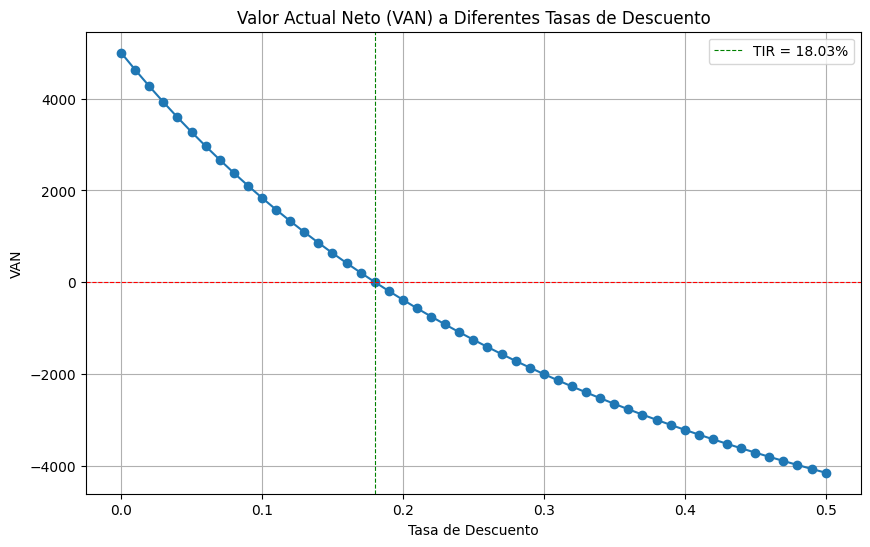

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import numpy_financial as nf

# Definir los flujos de caja del proyecto (usaremos los del ejercicio anterior)
flujos_van_viz = flujos_ejercicio

# Crear un rango de tasas de descuento para evaluar el VAN
# Por ejemplo, de 0% a 50% con incrementos de 1%
tasas_descuento_rango = np.arange(0, 0.51, 0.01)

# Calcular el VAN para cada tasa de descuento en el rango
van_por_tasa = [nf.npv(tasa, flujos_van_viz) for tasa in tasas_descuento_rango]

# Visualizar el VAN a distintas tasas de descuento
plt.figure(figsize=(10, 6))
plt.plot(tasas_descuento_rango, van_por_tasa, marker='o', linestyle='-')
plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Línea en VAN = 0 para identificar la TIR
plt.axvline(tir_ejercicio, color='green', linestyle='--', linewidth=0.8, label=f'TIR = {tir_ejercicio:.2%}') # Mostrar la TIR
plt.legend()
plt.show()

Ejercicio 2

---





In [24]:
# Definimos los flujos de caja del nuevo proyecto de inversión (incluyendo la inversión inicial)
nuevos_flujos_ejercicio = [-20000, 5000, 4000, 3000, 3000, 2000, 2000, 1500, 1500, 1000, 1000]

# Vemos los nuevos flujos de caja
print("Nuevos Flujos de Caja del Ejercicio:", nuevos_flujos_ejercicio)

Nuevos Flujos de Caja del Ejercicio: [-20000, 5000, 4000, 3000, 3000, 2000, 2000, 1500, 1500, 1000, 1000]


In [25]:
# Definimos la tasa de descuento (costo de capital) para el nuevo proyecto
nueva_tasa_descuento_ejercicio = 0.12  # 12%

# Imprimir la tasa de descuento
print("Nueva Tasa de Descuento:", nueva_tasa_descuento_ejercicio)

Nueva Tasa de Descuento: 0.12


In [ ]:
# Calculamos métricas financieras
# Calculamos el VAN
van_nuevos = nf.npv(nueva_tasa_descuento_ejercicio, nuevos_flujos_ejercicio)
print(f"\nEl Valor Actual Neto (VAN) es: {van_nuevos:.2f}")

# Calculamos la TIR
tir_nuevos = nf.irr(nuevos_flujos_ejercicio)
print(f"La Tasa Interna de Retorno (TIR) es: {tir_nuevos:.2%}")

# Calculamos la TIRM

tasa_financiamiento_nuevos = nueva_tasa_descuento_ejercicio
tasa_reinversion_nuevos = nueva_tasa_descuento_ejercicio
tirm_nuevos = nf.mirr(nuevos_flujos_ejercicio, tasa_financiamiento_nuevos, tasa_reinversion_nuevos)
print(f"La Tasa Interna de Retorno Modificada (TIRM) es: {tirm_nuevos:.2%}")

# Calculamos el IR

inversion_inicial_nuevos = abs(nuevos_flujos_ejercicio[0])
# Calculamos el VAN para el numerador
van_flujos_futuros_nuevos = nf.npv(nueva_tasa_descuento_ejercicio, nuevos_flujos_ejercicio[1:])

sum_pv_future_flows = sum([flow / (1 + nueva_tasa_descuento_ejercicio)**t for t, flow in enumerate(nuevos_flujos_ejercicio[1:], start=1)])
ir_nuevos = sum_pv_future_flows / inversion_inicial_nuevos
print(f"El Índice de Rentabilidad (IR) es: {ir_nuevos:.2f}")

# Calculamos el PRS
cash_flow_acumulado_nuevos = 0
prs_nuevos = None
for t in range(len(nuevos_flujos_ejercicio)):
    cash_flow_acumulado_nuevos += nuevos_flujos_ejercicio[t]
    if cash_flow_acumulado_nuevos >= 0 and prs_nuevos is None:

        previous_cumulative_flow_nuevos = cash_flow_acumulado_nuevos - nuevos_flujos_ejercicio[t]
        remaining_needed_nuevos = abs(previous_cumulative_flow_nuevos)

        if nuevos_flujos_ejercicio[t] > 0:
             prs_nuevos = t -1 + (remaining_needed_nuevos / nuevos_flujos_ejercicio[t])
        else:

             continue
        break

if prs_nuevos is not None:

    print(f"El Periodo de Recuperación Simple (PRS) es: {prs_nuevos:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis simple.")

# Calculamos el PRD
cash_flow_acumulado_descontado_nuevos = 0
prd_nuevos = None

for t in range(len(nuevos_flujos_ejercicio)):

    if t == 0:
        discounted_flow_nuevos = nuevos_flujos_ejercicio[t]
    else:
        discounted_flow_nuevos = nuevos_flujos_ejercicio[t] / (1 + nueva_tasa_descuento_ejercicio)**t

    cash_flow_acumulado_descontado_nuevos += discounted_flow_nuevos


    if cash_flow_acumulado_descontado_nuevos >= 0 and prd_nuevos is None:

        previous_cumulative_discounted_flow_nuevos = cash_flow_acumulado_descontado_nuevos - discounted_flow_nuevos
        remaining_needed_discounted_nuevos = abs(previous_cumulative_discounted_flow_nuevos)

        if discounted_flow_nuevos > 0:

             prd_nuevos = t - 1 + (remaining_needed_discounted_nuevos / discounted_flow_nuevos)
        else:

            continue
        break

if prd_nuevos is not None:
     print(f"El Periodo de Recuperación Descontado (PRD) es: {prd_nuevos:.2f} años")
else:
    print("La inversión inicial no se recupera dentro del período del análisis descontado.")


El Valor Actual Neto (VAN) es: -4190.00
La Tasa Interna de Retorno (TIR) es: 4.79%
La Tasa Interna de Retorno Modificada (TIRM) es: 9.40%
El Índice de Rentabilidad (IR) es: 0.79
El Periodo de Recuperación Simple (PRS) es: 6.67 años
La inversión inicial no se recupera dentro del período del análisis descontado.


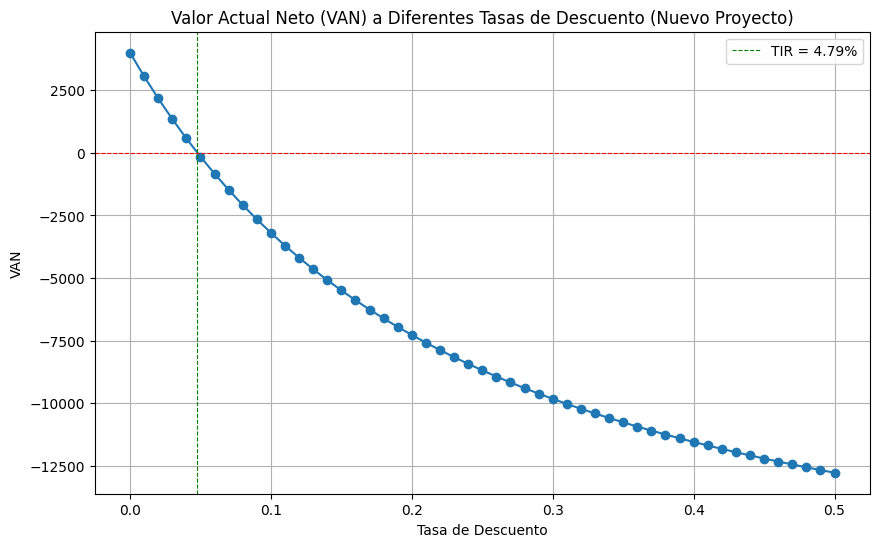

In [27]:
# Creamos un rango de tasas para evaluar el VAN

tasas_descuento_rango_nuevos = np.arange(0, 0.51, 0.01)

# Calculamos el VAN para cada tasa de descuento
van_por_tasa_nuevos = [nf.npv(tasa, nuevos_flujos_ejercicio) for tasa in tasas_descuento_rango_nuevos]

# Visualizamos el VAN a distintas tasas de descuento
plt.figure(figsize=(10, 6))
plt.plot(tasas_descuento_rango_nuevos, van_por_tasa_nuevos, marker='o', linestyle='-')
plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento (Nuevo Proyecto)')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Línea en VAN = 0 para identificar la TIR

if 0 <= tir_nuevos <= 0.50:
    plt.axvline(tir_nuevos, color='green', linestyle='--', linewidth=0.8, label=f'TIR = {tir_nuevos:.2%}') # Mostrar la TIR
plt.legend()
plt.show()

--- Análisis del Nuevo Proyecto de Inversión ---

Valor Actual Neto (VAN): -4190.00

Tasa Interna de Retorno (TIR): 4.79%

Tasa Interna de Retorno Modificada (TIRM): 9.40%

Índice de Rentabilidad (IR): 0.79

Periodo de Recuperación Simple (PRS): 6.67 años

Periodo de Recuperación Descontado (PRD): La inversión inicial no se recupera descontada.

Tasa de Descuento (Costo de Capital): 12.00%

---



Comparación con la Tasa de Descuento:
- La TIR (4.79%) es MENOR que la tasa de descuento (12.00%). Según el criterio de la TIR, el proyecto NO parece rentable.
- La TIRM (9.40%) es MENOR que la tasa de descuento (12.00%). Según el criterio de la TIRM, el proyecto NO parece rentable.

Interpretación del Índice de Rentabilidad (IR):
- El IR (0.79) es MENOR que 1. Esto indica que por cada unidad monetaria invertida, se espera recibir 0.79 unidades monetarias en valor presente de flujos futuros. El proyecto NO parece rentable según el IR.

Análisis de los Periodos de Recuperación:
- El Periodo de Recuperación Simple (PRS) es de 6.67 años. Este es el tiempo estimado para recuperar la inversión inicial sin descontar los flujos.
- El Periodo de Recuperación Descontado (PRD): La inversión inicial no se recupera dentro del período de análisis descontado. Esto es consistente con un VAN negativo, ya que el VAN negativo implica que los flujos descontados totales son menores que la inversión inicial, por lo tanto, la inversión inicial no se recupera en valor presente.

---



Observación del Gráfico del VAN:
- El gráfico muestra la relación entre la tasa de descuento y el VAN.
- La Tasa Interna de Retorno (TIR) calculada (4.79%) es el punto donde la curva del VAN cruza el eje horizontal (VAN = 0).
- Dado que el VAN es negativo para la tasa de descuento del 12%, la curva del VAN está por debajo del eje horizontal en este punto.

--- Resumen General de la Evaluación del Proyecto ---

Según la mayoría de las métricas (VAN, TIR, TIRM, IR), el proyecto NO parece ser RENTABLE a una tasa de descuento del 12%.
La inversión simple se recuperaría en aproximadamente 6.67 años, pero la inversión descontada NO se recupera dentro del período de análisis.

---



Ejercicio 3 - Comparamos 2 proyectos

---



In [28]:
# Definimos los flujos de caja para el Proyecto A
flujos_proyecto_a = [-15000, 6000, 5000, 4000, 3000, 2000]

# Definimos los flujos de caja para el Proyecto B
flujos_proyecto_b = [-20000, 4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000]

# Imprimimos los flujos de caja para verificar
print("Flujos de Caja del Proyecto A:", flujos_proyecto_a)
print("Flujos de Caja del Proyecto B:", flujos_proyecto_b)

Flujos de Caja del Proyecto A: [-15000, 6000, 5000, 4000, 3000, 2000]
Flujos de Caja del Proyecto B: [-20000, 4000, 4000, 4000, 4000, 4000, 4000, 4000, 4000]


In [29]:
# Definimos la tasa de descuento común para ambos proyectos
tasa_descuento_comun = 0.15  # 15%

# Imprimimos la tasa de descuento para verificación
print(f"Tasa de Descuento Común para ambos proyectos: {tasa_descuento_comun:.2%}")

Tasa de Descuento Común para ambos proyectos: 15.00%


In [ ]:
#Métricas

# Calculamos métricas para el  Projecto A
van_proyecto_a = nf.npv(tasa_descuento_comun, flujos_proyecto_a)
tir_proyecto_a = nf.irr(flujos_proyecto_a)
tirm_proyecto_a = nf.mirr(flujos_proyecto_a, tasa_descuento_comun, tasa_descuento_comun)

# Calculamos IR
inversion_inicial_a = abs(flujos_proyecto_a[0])
sum_pv_future_flows_a = sum([flow / (1 + tasa_descuento_comun)**t for t, flow in enumerate(flujos_proyecto_a[1:], start=1)])
ir_proyecto_a = sum_pv_future_flows_a / inversion_inicial_a

# Calculamos PRS
cash_flow_acumulado_a = 0
prs_proyecto_a = None
for t in range(len(flujos_proyecto_a)):
    cash_flow_acumulado_a += flujos_proyecto_a[t]
    if cash_flow_acumulado_a >= 0 and prs_proyecto_a is None:
        previous_cumulative_flow_a = cash_flow_acumulado_a - flujos_proyecto_a[t]
        remaining_needed_a = abs(previous_cumulative_flow_a)
        if flujos_proyecto_a[t] > 0:
            prs_proyecto_a = t -1 + (remaining_needed_a / flujos_proyecto_a[t])
        else:
            continue
        break

# Calculamos PRD
cash_flow_acumulado_descontado_a = 0
prd_proyecto_a = None
for t in range(len(flujos_proyecto_a)):
    if t == 0:
        discounted_flow_a = flujos_proyecto_a[t]
    else:
        discounted_flow_a = flujos_proyecto_a[t] / (1 + tasa_descuento_comun)**t
    cash_flow_acumulado_descontado_a += discounted_flow_a

    if cash_flow_acumulado_descontado_a >= 0 and prd_proyecto_a is None:
        previous_cumulative_discounted_flow_a = cash_flow_acumulado_descontado_a - discounted_flow_a
        remaining_needed_discounted_a = abs(previous_cumulative_discounted_flow_a)
        if discounted_flow_a > 0:
             prd_proyecto_a = t - 1 + (remaining_needed_discounted_a / discounted_flow_a)
        else:
            continue
        break


# Calculamos métricas para el Projecto B
van_proyecto_b = nf.npv(tasa_descuento_comun, flujos_proyecto_b)
tir_proyecto_b = nf.irr(flujos_proyecto_b)
tirm_proyecto_b = nf.mirr(flujos_proyecto_b, tasa_descuento_comun, tasa_descuento_comun)

# Calculamos IR
inversion_inicial_b = abs(flujos_proyecto_b[0])
sum_pv_future_flows_b = sum([flow / (1 + tasa_descuento_comun)**t for t, flow in enumerate(flujos_proyecto_b[1:], start=1)])
ir_proyecto_b = sum_pv_future_flows_b / inversion_inicial_b

# Calculamos PRS
cash_flow_acumulado_b = 0
prs_proyecto_b = None
for t in range(len(flujos_proyecto_b)):
    cash_flow_acumulado_b += flujos_proyecto_b[t]
    if cash_flow_acumulado_b >= 0 and prs_proyecto_b is None:
        previous_cumulative_flow_b = cash_flow_acumulado_b - flujos_proyecto_b[t]
        remaining_needed_b = abs(previous_cumulative_flow_b)
        if flujos_proyecto_b[t] > 0:
            prs_proyecto_b = t -1 + (remaining_needed_b / flujos_proyecto_b[t])
        else:
            continue
        break

# Calculamos PRD
cash_flow_acumulado_descontado_b = 0
prd_proyecto_b = None
for t in range(len(flujos_proyecto_b)):
    if t == 0:
        discounted_flow_b = flujos_proyecto_b[t]
    else:
        discounted_flow_b = flujos_proyecto_b[t] / (1 + tasa_descuento_comun)**t
    cash_flow_acumulado_descontado_b += discounted_flow_b

    if cash_flow_acumulado_descontado_b >= 0 and prd_proyecto_b is None:
        previous_cash_flow_acumulado_descontado_b = cash_flow_acumulado_descontado_b - discounted_flow_b
        remaining_needed_discounted_b = abs(previous_cash_flow_acumulado_descontado_b)
        if discounted_flow_b > 0:
             prd_proyecto_b = t - 1 + (remaining_needed_discounted_b / discounted_flow_b)
        else:
            continue
        break


# Resultados
print("\nMétricas Financieras para Proyectos de Inversión")
print("-" * 40)

print("\nProyecto A:")
print(f"  VAN: {van_proyecto_a:.2f}")
print(f"  TIR: {tir_proyecto_a:.2%}")
print(f"  TIRM: {tirm_proyecto_a:.2%}")
print(f"  IR: {ir_proyecto_a:.2f}")
if prs_proyecto_a is not None:
    print(f"  PRS: {prs_proyecto_a:.2f} años")
else:
    print("  PRS: La inversión inicial no se recupera.")
if prd_proyecto_a is not None:
    print(f"  PRD: {prd_proyecto_a:.2f} años")
else:
     print("  PRD: La inversión inicial no se recupera descontada.")


print("\nProyecto B:")
print(f"  VAN: {van_proyecto_b:.2f}")
print(f"  TIR: {tir_proyecto_b:.2%}")
print(f"  TIRM: {tirm_proyecto_b:.2%}")
print(f"  IR: {ir_proyecto_b:.2f}")
if prs_proyecto_b is not None:
    print(f"  PRS: {prs_proyecto_b:.2f} años")
else:
    print("  PRS: La inversión inicial no se recupera.")
if prd_proyecto_b is not None:
    print(f"  PRD: {prd_proyecto_b:.2f} años")
else:
     print("  PRD: La inversión inicial no se recupera descontada.")


Métricas Financieras para Proyectos de Inversión
----------------------------------------

Proyecto A:
  VAN: -662.21
  TIR: 12.75%
  TIRM: 13.97%
  IR: 0.96
  PRS: 3.00 años
  PRD: La inversión inicial no se recupera descontada.

Proyecto B:
  VAN: -2050.71
  TIR: 11.81%
  TIRM: 13.46%
  IR: 0.90
  PRS: 5.00 años
  PRD: La inversión inicial no se recupera descontada.


--- Comparación de Proyectos de Inversión ---

Proyecto A:

  VAN: -662.21 - Proyecto A es menos desfavorable (VAN más cercano a cero o mayor)

  TIR: 12.75% - Proyecto A es mejor (TIR más alta)

  TIRM: 13.97% - Proyecto A es mejor (TIRM más alta)

  IR: 0.96 - Proyecto A es mejor (IR más alto)

  PRS: 3.00 años - Proyecto A es mejor (recupera antes)

  PRD: Ningún proyecto recupera la inversión descontada dentro del período.

---



Proyecto B:

  VAN: -2050.71

  TIR: 11.81%

  TIRM: 13.46%

  IR: 0.90

  PRS: 5.00 años

  PRD: La inversión inicial no se recupera descontada.

---



--- Resumen de la Comparación ---
- Según el VAN, el Proyecto A es preferible ya que tiene un VAN menos negativo (o más positivo).
- Según la TIR, el Proyecto A es preferible ya que ofrece una mayor tasa de retorno.
- Según la TIRM, el Proyecto A es preferible ya que ofrece una mayor tasa de retorno modificada.
- Según el Índice de Rentabilidad (IR), el Proyecto A es preferible ya que genera más valor presente por cada unidad invertida.
- Según el Periodo de Recuperación Simple (PRS), el Proyecto A es preferible ya que recupera la inversión inicial más rápido.
- Según el Periodo de Recuperación Descontado (PRD), ninguno de los proyectos recupera la inversión inicial descontada.

Conclusión General:
Ambos proyectos tienen un Valor Actual Neto (VAN) negativo y un Índice de Rentabilidad (IR) menor que 1 a la tasa de descuento del 15%, lo que indica que ninguno de los dos proyectos es financieramente rentable según estos criterios.
Además, ninguno de los proyectos recupera la inversión inicial cuando se descuentan los flujos (PRD no recuperado).
Sin embargo, al comparar los dos proyectos:
- El Proyecto A presenta un VAN menos negativo (-662.21) en comparación con el Proyecto B (-2050.71).
- El Proyecto A tiene una TIR (12.75%) y una TIRM (13.97%) más altas que el Proyecto B (TIR: 11.81%, TIRM: 13.46%).
- El Proyecto A tiene un Índice de Rentabilidad (0.96) mayor que el Proyecto B (0.90).
- El Proyecto A recupera la inversión inicial simple más rápido (3.00 años) que el Proyecto B (5.00 años).

Basándose en estas métricas comparativas, aunque ninguno de los proyectos cumple con los criterios de aceptación tradicionales (VAN>0, IR>1, PRD recuperado), el Proyecto A es menos desfavorable y presenta mejores indicadores de rentabilidad y liquidez que el Proyecto B en este escenario.


---




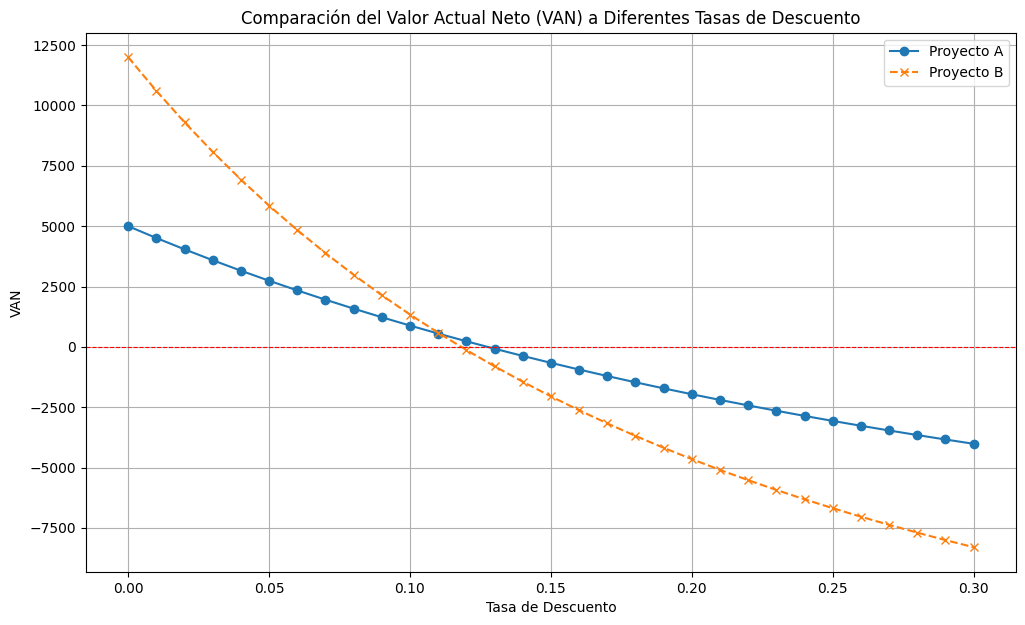

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import numpy_financial as nf

# Definimos rango de tasas de descuento
tasas_descuento_rango = np.arange(0, 0.31, 0.01)

# Calculamos VAN para cada tasa en el  Projecto A
van_proyecto_a_rango = [nf.npv(tasa, flujos_proyecto_a) for tasa in tasas_descuento_rango]

# Calculamos VAN para cada tasa en el  Projecto B
van_proyecto_b_rango = [nf.npv(tasa, flujos_proyecto_b) for tasa in tasas_descuento_rango]

# Creamos el gráfico
plt.figure(figsize=(12, 7))
plt.plot(tasas_descuento_rango, van_proyecto_a_rango, marker='o', linestyle='-', label='Proyecto A')
plt.plot(tasas_descuento_rango, van_proyecto_b_rango, marker='x', linestyle='--', label='Proyecto B')


plt.title('Comparación del Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')


plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.legend()
plt.show()

### 🔀 El cruce de las curvas: cuando VAN y TIR se contradicen (punto de Fisher)

Mirá bien el gráfico de arriba: las dos curvas **se cruzan** en un punto. Ese punto se llama **punto de Fisher** y acá está en torno al **11,1%**. Es la tasa de descuento a la que **ambos proyectos tienen el mismo VAN**.

Y acá aparece algo que confunde a todo el mundo 🤯: **VAN y TIR pueden recomendarte proyectos distintos.**

- La **TIR** dice siempre lo mismo: gana **A** (12,75% > 11,81%), no importa la tasa.
- El **VAN** depende de dónde estés parado:
  - 📉 Si tu costo de capital está **por debajo** del 11,1% → gana **B** (su curva está más arriba, mayor VAN).
  - 📈 Si está **por encima** del 11,1% → gana **A**.

> ⚖️ **¿A quién le hago caso?** Cuando hay conflicto entre proyectos **mutuamente excluyentes** (elegís uno solo), **gana el VAN**. ¿Por qué? Porque el VAN mide **plata concreta** que sumás hoy, mientras que la TIR es solo un porcentaje que ignora el **tamaño** del proyecto. B invierte más (20k vs 15k) y a tasas bajas eso genera más valor absoluto, aunque su "porcentaje" sea menor.

🎯 *Moraleja para un analista:* nunca mires una sola métrica. La TIR es cómoda para comunicar ("¡rinde 12%!"), pero el VAN es el que te dice **cuánta plata ganás de verdad**. El punto de Fisher es el recordatorio de que **la tasa que elegís puede dar vuelta la decisión.**

Interpretación del Gráfico Comparativo del VAN:
- El gráfico muestra cómo el VAN de cada proyecto cambia a medida que varía la tasa de descuento.
- La TIR de cada proyecto (12.75% para el Proyecto A y 11.81% para el Proyecto B) corresponde al punto donde su respectiva curva cruza el eje horizontal (VAN = 0).

Comparación de las Curvas del VAN:
- La curva del Proyecto A cruza el eje horizontal a una tasa de descuento más alta (12.75%) que la curva del Proyecto B (11.81%). Esto visualmente confirma que el Proyecto A tiene una TIR más alta.
- Para tasas de descuento por debajo de la TIR del Proyecto B (11.81%), ambos proyectos tienen VANs positivos. En este rango, el proyecto con la curva más alta (mayor VAN) sería preferible.
- Para tasas de descuento entre la TIR del Proyecto B (11.81%) y la TIR del Proyecto A (12.75%), el Proyecto A tiene un VAN positivo mientras que el Proyecto B tiene un VAN negativo. En este rango, solo el Proyecto A sería aceptable según el criterio del VAN.
- Para tasas de descuento por encima de la TIR del Proyecto A (12.75%), ambos proyectos tienen VANs negativos. En este rango, el proyecto con el VAN menos negativo (la curva más alta) sería el menos desfavorable.

---

